# 08 発展課題（自作） 解答 — sRNA 競合
対象: [`notebooks/08_srna_competition.ipynb`](../notebooks/08_srna_competition.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
H = Species('H'); BETA,KA,KD,K5 = 1.0,1.0,1.0,10.0
def R(a,b,k): return ReactionRule(a,b,k)
def pair(i, a_s, a_m, ka_s=1.0):
    s,m,sH,mH,T,D = (Species(f'{x}{i}') for x in ['s','m','sH','mH','T','D'])
    return [R([],[s],a_s),R([],[m],a_m),R([s],[],BETA),R([m],[],BETA),
            R([s,H],[sH],ka_s),R([sH],[s,H],KD),R([m,H],[mH],KA),R([mH],[m,H],KD),
            R([sH,m],[T],KA),R([T],[sH,m],KD),R([mH,s],[T],KA),R([T],[mH,s],KD),
            R([T],[D,H],K5),R([sH],[H],BETA),R([mH],[H],BETA),R([T],[H],BETA),R([D],[],BETA)]
def run_pairs(h_tot, specs):
    names=['H']+[f'{x}{i}' for i,_ in enumerate(specs,1) for x in ['s','m','sH','mH','T','D']]
    mdl=NetworkModel()
    for i,(a_s,a_m,ka_s) in enumerate(specs,1):
        for r in pair(i,a_s,a_m,ka_s): mdl.add_reaction_rule(r)
    v=dict(zip(names, run_simulation(600.0,y0={'H':h_tot},model=mdl,solver='ode',ndiv=1,species_list=names).as_array()[-1][1:]))
    def act(i): tot=v[f'm{i}']+v[f'mH{i}']+v[f'T{i}']+v[f'D{i}']; return 100*v[f'D{i}']/tot if tot>0 else 0.0
    return [act(i) for i in range(1,len(specs)+1)]

## Q1. s1 の Hfq 結合を強く（`ka_s` ↑）＝「強い競合者」

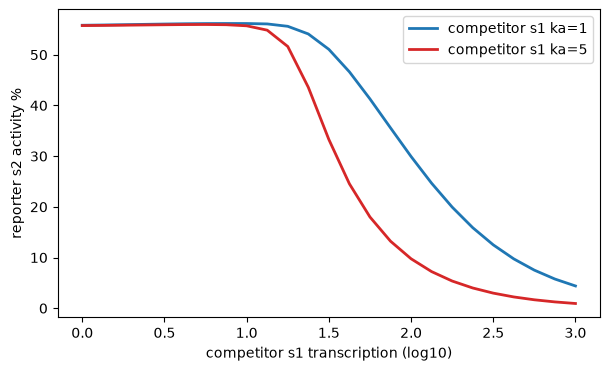

In [2]:
a1=np.logspace(0,3,25); fig,ax=plt.subplots(figsize=(7,4))
for ka1,c in [(1.0,'C0'),(5.0,'C3')]:
    y=[run_pairs(12.0, [(a,10.0,ka1),(10.0,10.0,1.0)])[1] for a in a1]  # s2 = reporter
    ax.plot(np.log10(a1),y,color=c,lw=2,label=f'competitor s1 ka={ka1:.0f}')
ax.set_xlabel('competitor s1 transcription (log10)'); ax.set_ylabel('reporter s2 activity %'); ax.legend(); plt.show()

**答**: s1 の Hfq 結合を強めると（ka=5）、**より少ない発現量でレポーター s2 を抑えられる**（曲線が左へシフト）。Hfq を奪う効率が上がった「強い競合者」。sRNA の Hfq 親和性は競合力を直接左右する。

## Q2. 3つ目の sRNA s3 を足して、親和性ヒエラルキーで誰が勝つか

In [3]:
# 3 sRNA が Hfq(律速=12) を奪い合う。転写は同じ、Hfq 親和性 ka だけ違う
acts = run_pairs(12.0, [(10.0,10.0,3.0),(10.0,10.0,1.0),(10.0,10.0,0.3)])
for i,(name,ka) in enumerate(zip(['s1 (ka=3)','s2 (ka=1)','s3 (ka=0.3)'],[3,1,0.3])):
    print(f'{name}: activity={acts[i]:.1f}%')

s1 (ka=3): activity=56.7%
s2 (ka=1): activity=54.5%
s3 (ka=0.3): activity=50.6%


**答**: 転写量が同じでも、**Hfq 親和性が高い sRNA ほど活性が高い**（s1>s2>s3）。限られた Hfq をめぐる競合で「親和性のヒエラルキー」が勝敗を決める。誘導の順序（動的シナリオ）を入れると、先に誘導された高親和性 sRNA が Hfq を占有して後続を抑える、という時間的優先も加わる（→ 練習の発展）。

## Q3. レポーター m2 の転写量を変えると競合感受性は?

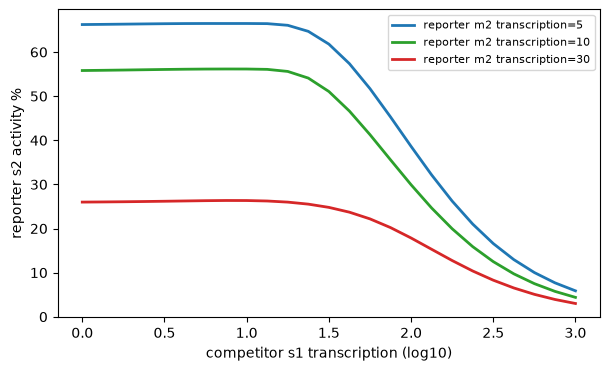

In [4]:
a1=np.logspace(0,3,25); fig,ax=plt.subplots(figsize=(7,4))
for am2,c in [(5.0,'C0'),(10.0,'C2'),(30.0,'C3')]:
    y=[run_pairs(12.0, [(a,10.0,1.0),(10.0,am2,1.0)])[1] for a in a1]
    ax.plot(np.log10(a1),y,color=c,lw=2,label=f'reporter m2 transcription={am2:.0f}')
ax.set_xlabel('competitor s1 transcription (log10)'); ax.set_ylabel('reporter s2 activity %'); ax.legend(fontsize=8); plt.show()

**答**: レポーターの標的 m2 の転写量を増やすと、s2 が処理すべき標的が増える一方、m2 も Hfq を要求するので競合の様相が変わる。概ね **m2 が多いほど %duplex（=処理率）は競合に対してやや頑健**になるが、絶対量の要求が増えるため単純ではない。標的量そのものが競合感受性を調整する変数になっている。

## Q4.（考察）bio-a: Hfq 親和性の系統差 → 競合ヒエラルキーの順位

**答（考察）**: Q1-Q2 が示すとおり、競合力は Hfq 親和性 `ka` で決まる。オーソログ間で Hfq の面（distal/proximal/rim）の保存が違えば sRNA/mRNA の実効親和性が変わり、**同じ sRNA セットでも系統ごとに競合ヒエラルキーの順位が入れ替わりうる**。Hfq や sRNA の配列進化を「奪い合いの強さ」の差として bio-e で定量する。